In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

from  lora_transfer_pruning.core.pruning_instrumentor import PruningInstrumentor
from transformers import AutoModelForCausalLM
import torch
import compare_utils
from compare_utils import debug_group_prune_step_by_step
from lora_transfer_pruning.adapter.torch_pruning_group_builder import TorchPruningGroupBuilder
from compare_utils import full_attention_test_with_prune

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


In [2]:
MODEL = "meta-llama/Llama-3.1-8B-Instruct" 
DEVICE = "cuda:3"
def load_model(device=DEVICE):
    model = AutoModelForCausalLM.from_pretrained(
        MODEL,
        #quantization_config=quantization_config,
        #dtype=torch.bfloat16,
        device_map=device,
        # cache_dir="/glazkov-dev/.cache",
    )
    return model

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL)
validation_dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split="validation",
)
validation_dataset

Dataset({
    features: ['text'],
    num_rows: 3760
})

In [4]:
for i, text in enumerate(validation_dataset):
    print(f"{i}: {text}")
    if i > 10:
        break

0: {'text': ''}
1: {'text': ' = Homarus gammarus = \n'}
2: {'text': ''}
3: {'text': ' Homarus gammarus , known as the European lobster or common lobster , is a species of clawed lobster from the eastern Atlantic Ocean , Mediterranean Sea and parts of the Black Sea . It is closely related to the American lobster , H. americanus . It may grow to a length of 60 cm ( 24 in ) and a mass of 6 kilograms ( 13 lb ) , and bears a conspicuous pair of claws . In life , the lobsters are blue , only becoming " lobster red " on cooking . Mating occurs in the summer , producing eggs which are carried by the females for up to a year before hatching into planktonic larvae . Homarus gammarus is a highly esteemed food , and is widely caught using lobster pots , mostly around the British Isles . \n'}
4: {'text': ''}
5: {'text': ' = = Description = = \n'}
6: {'text': ''}
7: {'text': ' Homarus gammarus is a large crustacean , with a body length up to 60 centimetres ( 24 in ) and weighing up to 5 – 6 kilogram

In [5]:
CONTEXT_LENGTH = 256
NUM_EVAL_BLOCKS = 256 #(block=batch)
EVAL_BATCH_SIZE = 1

validation_text = "\n\n".join(
    text for text in validation_dataset["text"] if text.strip()
)
validation_tokens = tokenizer(
    validation_text,
    add_special_tokens=False,
    return_tensors="pt",
).input_ids[0]

num_blocks = NUM_EVAL_BLOCKS
assert num_blocks > 0, "Validation split does not contain enough tokens"
evaluation_blocks = validation_tokens[: num_blocks * CONTEXT_LENGTH].reshape(
    num_blocks, CONTEXT_LENGTH
)
evaluation_blocks.shape

torch.Size([256, 256])

### Without MOE block, just mlp

### Learning with TP and ours

In [6]:
from prune_and_train_model_for_comparsion import full_load_prune_learn_pipeline
FRACTION_ATTN_LAYERS = [0, 8, 16] #32, 40]
FRACTION_MLP_LAYERS = [4, 12, 20] #30] 
#ATTN_OUT_FRACTION = 0.1
#MLP_OUT_FRACTION = 0.3 
ATTN_OUT_FRACTION = [1, 2, 99, 125] #157, 250] #q proj < 128!!!
MLP_OUT_FRACTION = [3, 5, 1000, 2000, 3001, 4002] #< 4096! #5003, 6004, 7005, 8006, 9007, 10009] #up proj
FRACTION_SEED = 0

In [7]:
optimizer_factory = lambda params: torch.optim.SGD( #works better than AdamW consuming lots of memory
    params,
    lr=1e-4,
    momentum=0.0,
    weight_decay=0.0,
)

In [12]:
NUM_STEPS = 500
PRINT_EVERY = 25

In [ ]:
our_history = full_load_prune_learn_pipeline(MODEL,
                               load_model,
                               evaluation_blocks,
                               
    FRACTION_ATTN_LAYERS, FRACTION_MLP_LAYERS, ATTN_OUT_FRACTION, MLP_OUT_FRACTION,
    is_torch_pruning=False,
    rescale=False,
    seed=FRACTION_SEED,
    batch_size=3,
    optimizer_factory=optimizer_factory,
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

fraction prune_task:
  blocks.0.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.8.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.16.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.4.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.12.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.20.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)


/glazkov-dev/LoRa-Transfer-Pruning/.venv/lib/python3.10/site-packages/torch_pruning/dependency/graph.py:390: UserWarning: Unwrapped parameters detected: ['model.layers.5._original_component.input_layernorm._original_component.weight', 'model.layers.10._original_component.input_layernorm._original_component.weight', 'model.layers.10._original_component.post_attention_layernorm._original_component.weight', 'model.layers.15._original_component.post_attention_layernorm._original_component.weight', 'model.layers.13._original_component.post_attention_layernorm._original_component.weight', 'model.layers.18._original_component.input_layernorm._original_component.weight', 'model.layers.18._original_component.post_attention_layernorm._original_component.weight', 'model.layers.20._original_component.input_layernorm._original_component.weight', 'model.layers.0._original_component.post_attention_layernorm._original_component.weight', 'model.layers.1._original_component.post_attention_layernorm._ori

removed group indices by module:
  blocks.0.attn.q_proj: count=256, idxs=[1, 2, 35, 61, 65, 66, 99, 125, 129, 130, 163, 189, 193, 194, 227, 253, 257, 258, 291, 317, 321, 322, 355, 381, 385, 386, 419, 445, 449, 450, 483, 509, 513, 514, 547, 573, 577, 578, 611, 637, 641, 642, 675, 701, 705, 706, 739, 765, 769, 770, 803, 829, 833, 834, 867, 893, 897, 898, 931, 957, 961, 962, 995, 1021, 1025, 1026, 1059, 1085, 1089, 1090, 1123, 1149, 1153, 1154, 1187, 1213, 1217, 1218, 1251, 1277, 1281, 1282, 1315, 1341, 1345, 1346, 1379, 1405, 1409, 1410, 1443, 1469, 1473, 1474, 1507, 1533, 1537, 1538, 1571, 1597, 1601, 1602, 1635, 1661, 1665, 1666, 1699, 1725, 1729, 1730, 1763, 1789, 1793, 1794, 1827, 1853, 1857, 1858, 1891, 1917, 1921, 1922, 1955, 1981, 1985, 1986, 2019, 2045, 2049, 2050, 2083, 2109, 2113, 2114, 2147, 2173, 2177, 2178, 2211, 2237, 2241, 2242, 2275, 2301, 2305, 2306, 2339, 2365, 2369, 2370, 2403, 2429, 2433, 2434, 2467, 2493, 2497, 2498, 2531, 2557, 2561, 2562, 2595, 2621, 2625, 2626, 26

In [9]:
our_history

[{'step': 1,
  'loss': 1.921875,
  'perplexity': 6.833759763883972,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 2,
  'loss': 2.125,
  'perplexity': 8.372897488127265,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 3,
  'loss': 2.265625,
  'perplexity': 9.637145935456955,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 4,
  'loss': 2.28125,
  'perplexity': 9.788908901255894,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 5,
  'loss': 2.125,
  'perplexity': 8.372897488127265,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 6,
  'loss': 2.375,
  'perplexity': 10.751013186076355,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 7,
  'loss': 2.53125,
  'perplexity': 12.569207830853442,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 8,
  'loss': 2.203125,
  'perplexity': 9.053260780008058,
  'gradient_norm': 0,
  'learning_rate': 1e-05},
 {'step': 9,
  'loss': 2.25,
  'perplexity': 9.487735836358526,
  'gradie

In [11]:
torch.cuda.empty_cache()

In [13]:
tp_history = full_load_prune_learn_pipeline(MODEL,
                               load_model,
                               evaluation_blocks,
                               
    FRACTION_ATTN_LAYERS, FRACTION_MLP_LAYERS, ATTN_OUT_FRACTION, MLP_OUT_FRACTION,
    is_torch_pruning=True,
    rescale=False,
    seed=FRACTION_SEED,
    batch_size=3,
    optimizer_factory=optimizer_factory,
    num_steps=NUM_STEPS,
    print_every=PRINT_EVERY
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

fraction prune_task:
  blocks.0.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.8.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.16.attn.q_proj: GroupPruneTask(cols=None, rows=[1, 2, 99, 125], kv_lora_idxs_deepseek=None)
  blocks.4.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.12.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)
  blocks.20.mlp.up_proj: GroupPruneTask(cols=None, rows=[3, 5, 1000, 2000, 3001, 4002], kv_lora_idxs_deepseek=None)


/glazkov-dev/LoRa-Transfer-Pruning/.venv/lib/python3.10/site-packages/torch_pruning/dependency/graph.py:390: UserWarning: Unwrapped parameters detected: ['model.layers.1._original_component.post_attention_layernorm._original_component.weight', 'model.layers.6._original_component.input_layernorm._original_component.weight', 'model.layers.13._original_component.post_attention_layernorm._original_component.weight', 'model.layers.15._original_component.input_layernorm._original_component.weight', 'model.layers.15._original_component.post_attention_layernorm._original_component.weight', 'model.layers.20._original_component.input_layernorm._original_component.weight', 'model.layers.20._original_component.post_attention_layernorm._original_component.weight', 'model.layers.25._original_component.input_layernorm._original_component.weight', 'model.layers.27._original_component.input_layernorm._original_component.weight', 'model.layers.13._original_component.input_layernorm._original_component.w

removed group indices by module:
  blocks.0.attn.q_proj: count=256, idxs=[1, 2, 35, 61, 65, 66, 99, 125, 129, 130, 163, 189, 193, 194, 227, 253, 257, 258, 291, 317, 321, 322, 355, 381, 385, 386, 419, 445, 449, 450, 483, 509, 513, 514, 547, 573, 577, 578, 611, 637, 641, 642, 675, 701, 705, 706, 739, 765, 769, 770, 803, 829, 833, 834, 867, 893, 897, 898, 931, 957, 961, 962, 995, 1021, 1025, 1026, 1059, 1085, 1089, 1090, 1123, 1149, 1153, 1154, 1187, 1213, 1217, 1218, 1251, 1277, 1281, 1282, 1315, 1341, 1345, 1346, 1379, 1405, 1409, 1410, 1443, 1469, 1473, 1474, 1507, 1533, 1537, 1538, 1571, 1597, 1601, 1602, 1635, 1661, 1665, 1666, 1699, 1725, 1729, 1730, 1763, 1789, 1793, 1794, 1827, 1853, 1857, 1858, 1891, 1917, 1921, 1922, 1955, 1981, 1985, 1986, 2019, 2045, 2049, 2050, 2083, 2109, 2113, 2114, 2147, 2173, 2177, 2178, 2211, 2237, 2241, 2242, 2275, 2301, 2305, 2306, 2339, 2365, 2369, 2370, 2403, 2429, 2433, 2434, 2467, 2493, 2497, 2498, 2531, 2557, 2561, 2562, 2595, 2621, 2625, 2626, 26

In [9]:
def plot_training_history(history, *, title="Training dynamics"):
    """Plot every numeric metric from a training history in one figure."""
    import math
    import numbers
    import matplotlib.pyplot as plt

    if not history:
        raise ValueError("history is empty")

    steps = [row.get("step", index + 1) for index, row in enumerate(history)]
    metric_names = [
        key for key in dict.fromkeys(key for row in history for key in row)
        if key != "step" and any(isinstance(row.get(key), numbers.Number) for row in history)
    ]
    if not metric_names:
        raise ValueError("history contains no numeric metrics")

    labels = {
        "loss": "Loss", "perplexity": "Perplexity",
        "gradient_norm": "Gradient norm", "learning_rate": "Learning rate",
    }
    ncols = min(2, len(metric_names))
    nrows = math.ceil(len(metric_names) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows),
                             squeeze=False, sharex=True)
    flat_axes = list(axes.flat)

    for ax, metric_name in zip(flat_axes, metric_names):
        values = [row.get(metric_name, float("nan")) for row in history]
        label = labels.get(metric_name, metric_name.replace("_", " ").title())
        ax.plot(steps, values, marker="o", linewidth=2, label=label)
        ax.set(title=label, xlabel="Training step", ylabel=label)
        ax.grid(True, alpha=0.3)
        ax.legend()
        if metric_name == "learning_rate":
            ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

    for ax in flat_axes[len(metric_names):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    return fig, axes


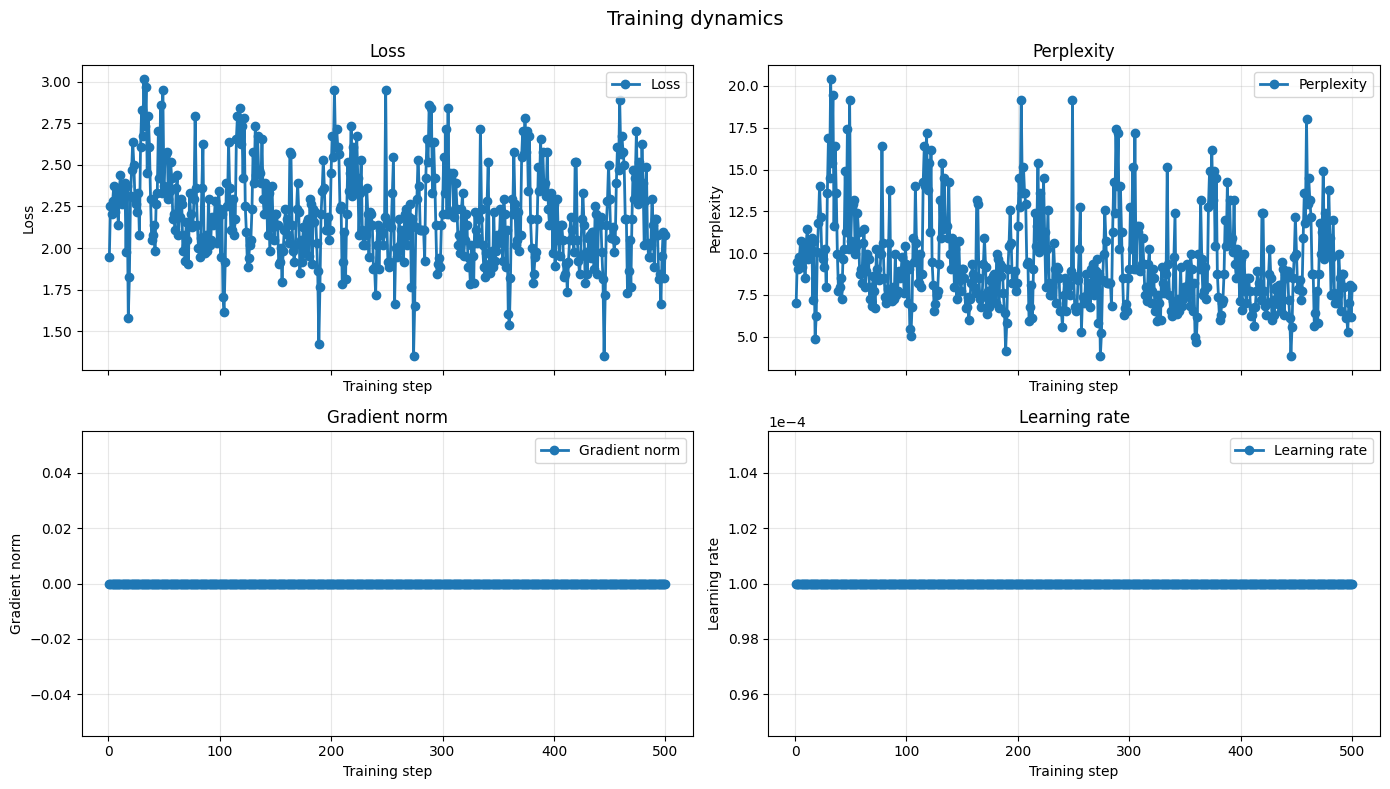

In [10]:
_ = plot_training_history(our_history)

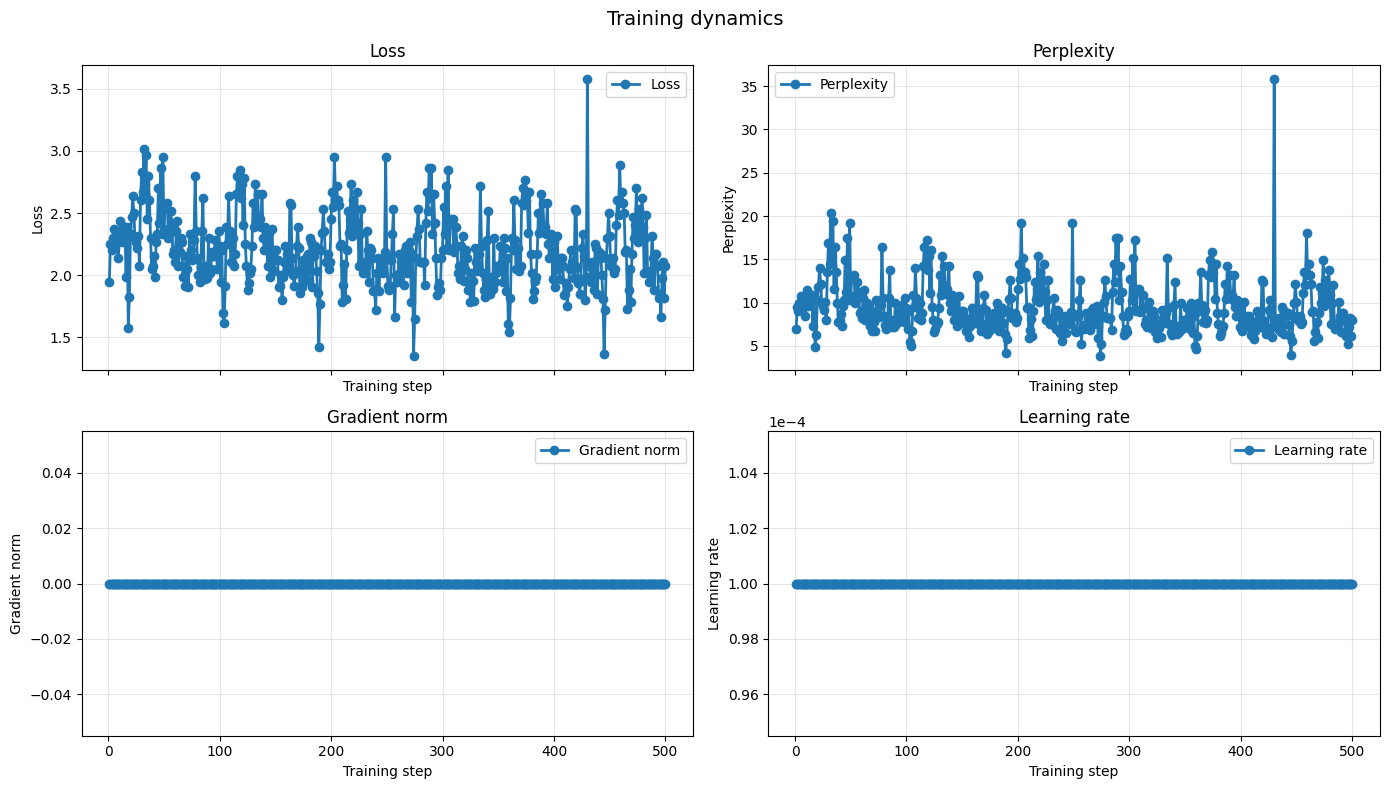

In [14]:
_ = plot_training_history(tp_history)